# Monte Carlo Methods - Week 3

In [1]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# define monte carlo agent:
class MonteCarloAgent:
    def __init__(self, epsilon, gamma, epsilon_decay):
        self.q_values = defaultdict(lambda: np.zeros(2))
        self.returns_sum = defaultdict(lambda: np.zeros(2))
        self.returns_count = defaultdict(lambda: np.zeros(2))
        self.epsilon = epsilon
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay

    def select_action(self, state, env):
        # Epsilon-greedy logic
        if np.random.random() < self.epsilon:
            return env.action_space.sample()
        return np.argmax(self.q_values[state])

    def update_policy(self):
        self.epsilon *= self.epsilon_decay
        self.epsilon = max(self.epsilon, 0.01)

def train(env, episodes=500000, epsilon=1.0, epsilon_decay=0.999999):
    agent = MonteCarloAgent(epsilon=epsilon, gamma=1.0, epsilon_decay=epsilon_decay)
    stats = []

    for i in range(episodes):
        state, info = env.reset()
        episode_data = []
        
        # 1. Generate Episode
        while True:
            action = agent.select_action(state, env)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_data.append((state, action, reward))
            state = next_state
            if terminated or truncated: # fixed logic from is not done
                break

        # 2. Process Returns (Backward)
        G = 0
        visited_state_actions = set()
        for s, a, r in reversed(episode_data):
            G = r + agent.gamma * G
            
            # First-visit check
            if (s, a) not in visited_state_actions:
                visited_state_actions.add((s, a))
                agent.returns_sum[s][a] += G
                agent.returns_count[s][a] += 1
                agent.q_values[s][a] = agent.returns_sum[s][a] / agent.returns_count[s][a]
        
        agent.update_policy()
        stats.append(G)
        
        if i % 50000 == 0:
            print(f"Episode {i}, Epsilon {agent.epsilon:.3f}")
            
    return agent, stats

# Run training
env = gym.make('Blackjack-v1')
agent, history = train(env)

Episode 0, Epsilon 1.000
Episode 50000, Epsilon 0.951
Episode 100000, Epsilon 0.905
Episode 150000, Epsilon 0.861
Episode 200000, Epsilon 0.819
Episode 250000, Epsilon 0.779
Episode 300000, Epsilon 0.741
Episode 350000, Epsilon 0.705
Episode 400000, Epsilon 0.670
Episode 450000, Epsilon 0.638


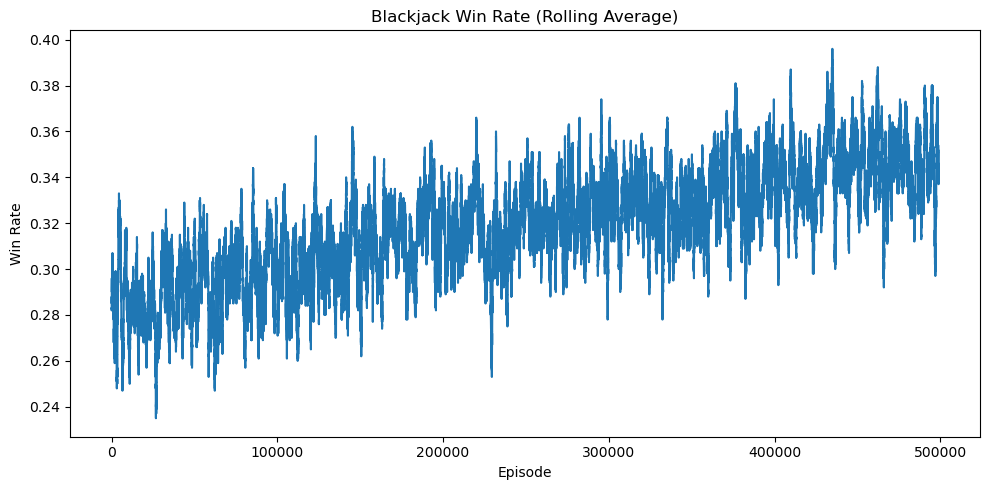

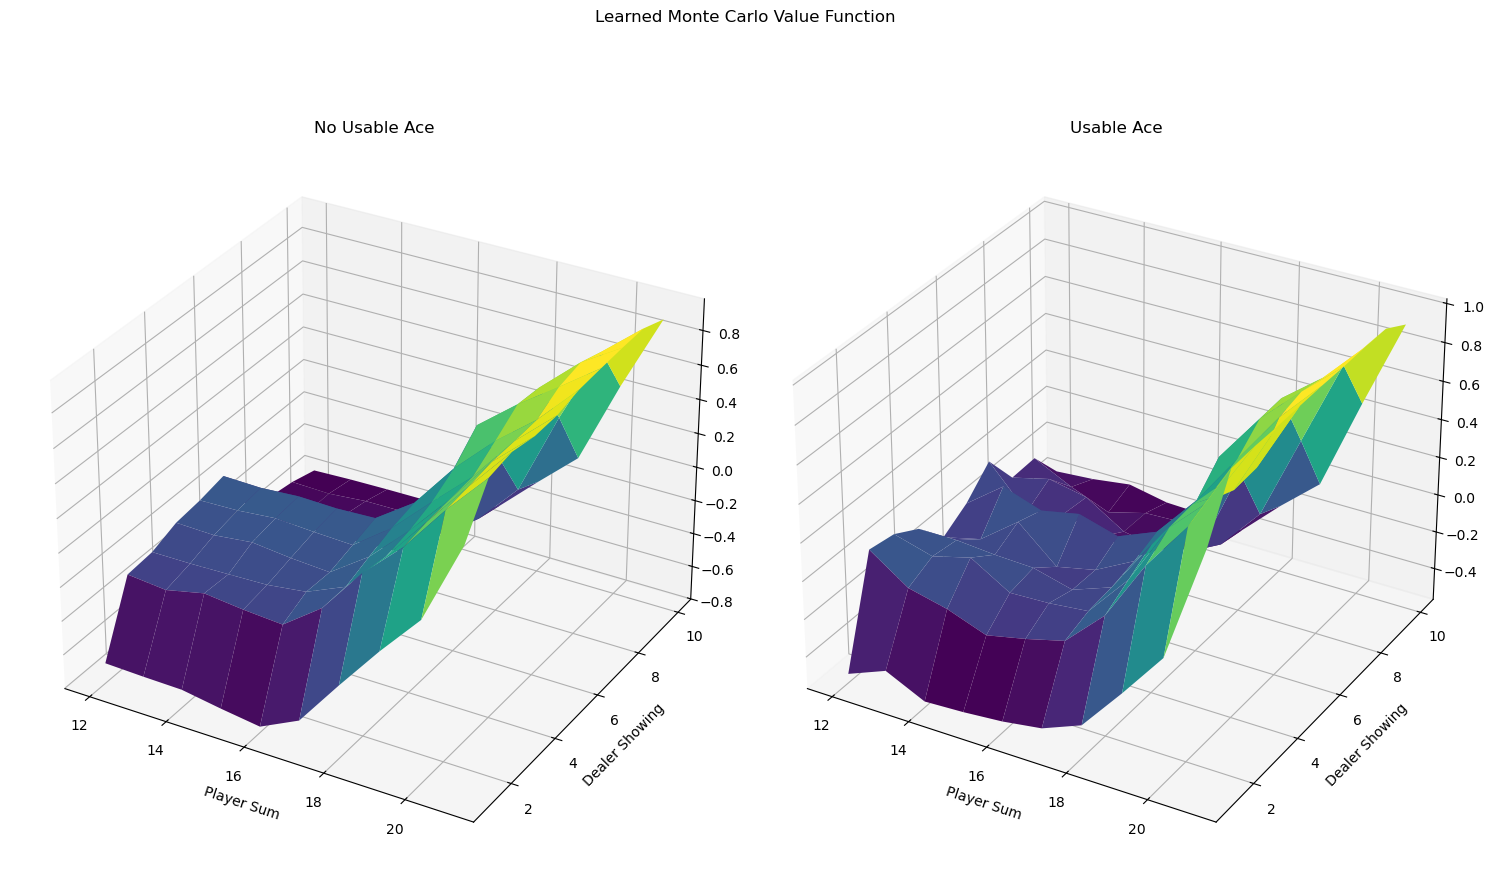

In [2]:
# win rate data
WINDOW = 1000
wins = [1 if r == 1 else 0 for r in history] # reward 1 = win
rolling_win_rate = np.convolve(wins, np.ones(WINDOW)/WINDOW, mode='valid')

# 3d plot data
def get_value_function(q_values):
    #V(s) = max_a Q(s, a)
    v = defaultdict(float)
    for state, actions in q_values.items():
        v[state] = np.max(actions)
    return v

value_func = get_value_function(agent.q_values)

from matplotlib import cm

def plot_blackjack_values(v, title):
    
    # define grid
    x_range = np.arange(12, 22) # player sum
    y_range = np.arange(1, 11) # dealer card
    X, Y = np.meshgrid(x_range, y_range)

    def get_z(usable_ace):
        return np.array([v[(x, y, usable_ace)] for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    fig = plt.figure(figsize=(15, 10))
    
    # plot no usable ace
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, get_z(False), cmap=cm.viridis)
    ax1.set_title('No Usable Ace')
    ax1.set_xlabel('Player Sum')
    ax1.set_ylabel('Dealer Showing')

    # plot usable ace
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, get_z(True), cmap=cm.viridis)
    ax2.set_title('Usable Ace')
    ax2.set_xlabel('Player Sum')
    ax2.set_ylabel('Dealer Showing')
    
    plt.suptitle(title)

    plt.tight_layout()
    plt.savefig('3d.png')
    plt.show()

# create plots
plt.figure(figsize=(10, 5))
plt.plot(rolling_win_rate)
plt.title("Blackjack Win Rate (Rolling Average)")
plt.xlabel("Episode")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.savefig('model.png')
plt.show()

plot_blackjack_values(value_func, "Learned Monte Carlo Value Function")

### Analysis Functions

/var/folders/lg/qjz9rnn97jq8zysv08gn0bm80000gn/T/ipykernel_373/320030064.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


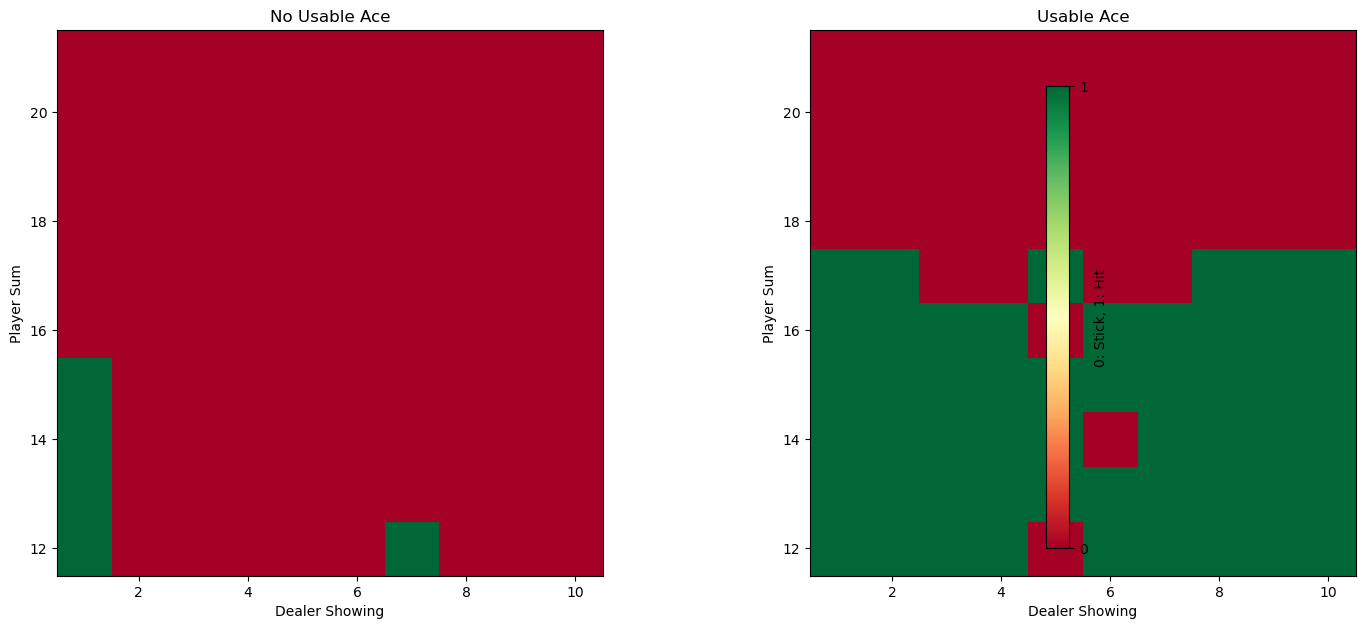

Testing decay rate: 0.999

Episode 0, Epsilon 0.999
Episode 50000, Epsilon 0.010
Testing decay rate: 0.9999

Episode 0, Epsilon 1.000
Episode 50000, Epsilon 0.010
Testing decay rate: 0.99999

Episode 0, Epsilon 1.000
Episode 50000, Epsilon 0.607
Testing decay rate: 0.999999

Episode 0, Epsilon 1.000
Episode 50000, Epsilon 0.951
Testing decay rate: 1.0

Episode 0, Epsilon 1.000
Episode 50000, Epsilon 1.000


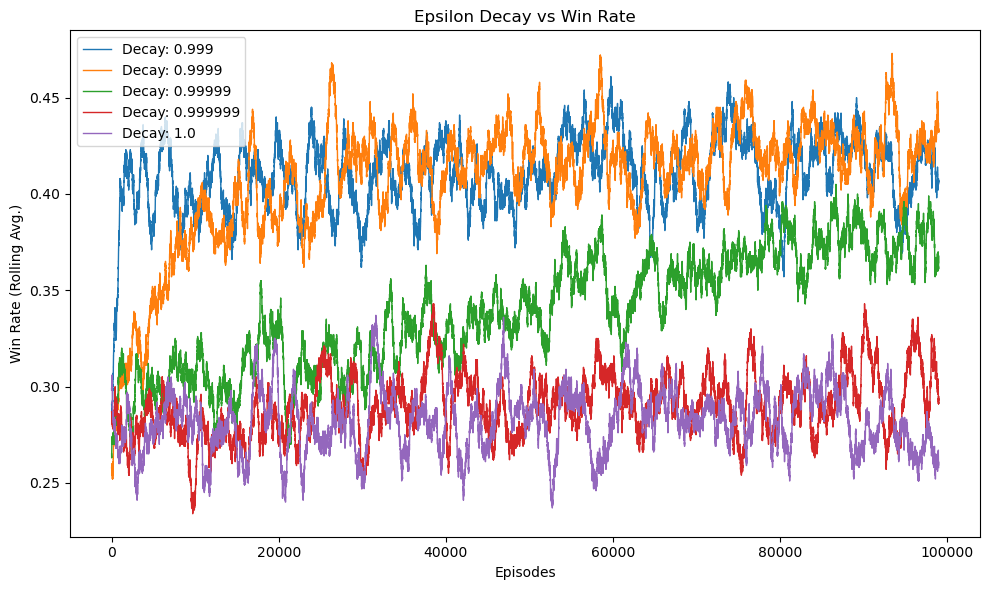

Testing epsilon: 0.0

Episode 0, Epsilon 0.010
Episode 50000, Epsilon 0.010
Testing epsilon: 0.1

Episode 0, Epsilon 0.100
Episode 50000, Epsilon 0.095
Testing epsilon: 0.5

Episode 0, Epsilon 0.500
Episode 50000, Epsilon 0.476
Testing epsilon: 0.9

Episode 0, Epsilon 0.900
Episode 50000, Epsilon 0.856
Testing epsilon: 1.0

Episode 0, Epsilon 1.000
Episode 50000, Epsilon 0.951


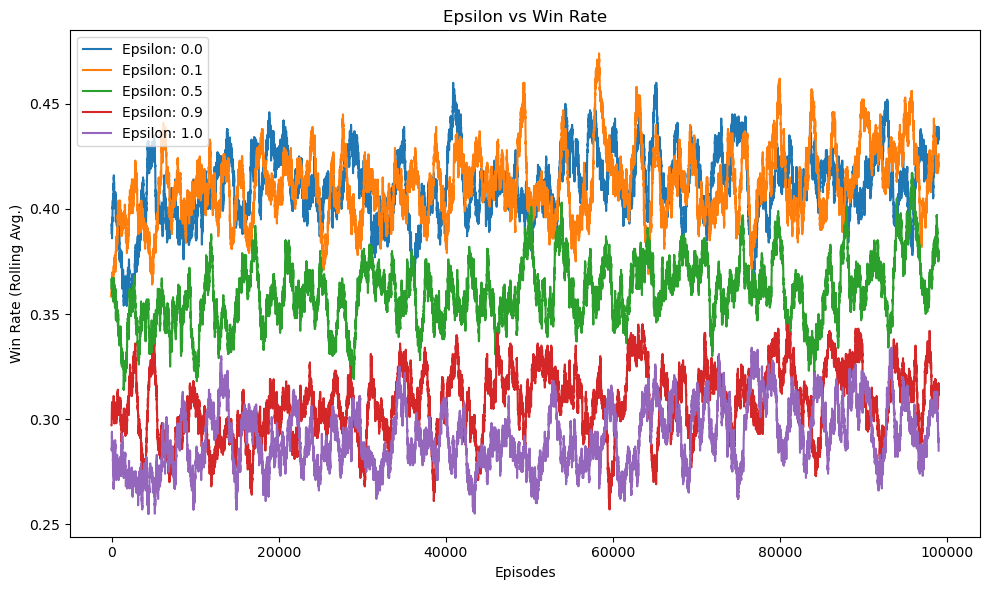

In [3]:
def plot_policy(q_values, title):
    # grids for usable and no usable ace
    x_range = np.arange(12, 22)  # player sum
    y_range = np.arange(1, 11)   # dealer showing
    
    def get_policy_grid(usable_ace):
        grid = np.zeros((len(x_range), len(y_range)))
        for i, x in enumerate(x_range):
            for j, y in enumerate(y_range):
                # policy is the argmax of Q-values
                grid[i, j] = np.argmax(q_values[(x, y, usable_ace)])
        return grid

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # plot no usable ace
    im1 = ax[0].imshow(get_policy_grid(False), origin='lower', 
                       extent=[0.5, 10.5, 11.5, 21.5], cmap='RdYlGn')
    ax[0].set_title('No Usable Ace')
    ax[0].set_ylabel('Player Sum')
    ax[0].set_xlabel('Dealer Showing')
    
    # plot usable ace
    im2 = ax[1].imshow(get_policy_grid(True), origin='lower', 
                       extent=[0.5, 10.5, 11.5, 21.5], cmap='RdYlGn')
    ax[1].set_title('Usable Ace')
    ax[1].set_ylabel('Player Sum')
    ax[1].set_xlabel('Dealer Showing')
    
    # colorbar: 0 is Stick (Red), 1 is Hit (Green)
    fig.colorbar(im1, ax=ax, ticks=[0, 1], label='0: Stick, 1: Hit')

    plt.tight_layout()
    plt.savefig('heatmap.png')
    plt.show()

def test_decay(decay_rates, episodes=100000):
    plt.figure(figsize=(10, 6))
    
    for decay in decay_rates:
        print(f'Testing decay rate: {decay}\n')
        env = gym.make('Blackjack-v1')
        agent, history = train(env, episodes=episodes, epsilon_decay=decay) # modify decay
        
        # rolling average
        wins = [1 if r == 1 else 0 for r in history]
        rolling = np.convolve(wins, np.ones(1000)/1000, mode='valid')
        plt.plot(rolling, label=f'Decay: {decay}', linewidth=1)
        
    plt.title('Epsilon Decay vs Win Rate')
    plt.xlabel('Episodes')
    plt.ylabel('Win Rate (Rolling Avg.)')
    plt.legend()

    plt.tight_layout()
    plt.savefig('decay_comparison.png')
    plt.show()
def test_epsilon(epsilons, episodes=100000):
    plt.figure(figsize=(10, 6))
    
    for epsilon in epsilons:
        print(f'Testing epsilon: {epsilon}\n')
        env = gym.make('Blackjack-v1')
        agent, history = train(env, episodes=episodes, epsilon=epsilon) # modify epsilon
        
        # rolling average
        wins = [1 if r == 1 else 0 for r in history]
        rolling = np.convolve(wins, np.ones(1000)/1000, mode='valid')
        plt.plot(rolling, label=f'Epsilon: {epsilon}')
        
    plt.title('Epsilon vs Win Rate')
    plt.xlabel('Episodes')
    plt.ylabel('Win Rate (Rolling Avg.)')
    plt.legend()

    plt.tight_layout()
    plt.savefig('epsilon_comparison.png')
    plt.show()
    
# plot
plot_policy(agent.q_values, "Learned Policy (Green=Hit, Red=Stick)")

# test various decays
test_decay([0.999, 0.9999, 0.99999, 0.999999, 1.0]) # 1.0 for no decay
test_epsilon([0.0, 0.1, 0.5, 0.9, 1.0]) # 1.0 for full exploration

## QUASAR comparison for fun

Initializing: Hyperellipsoid (N=16, D=200).

Evolving (sobol):
 Gen. 1/30 | f(x)=2.54e-01 | stdev=6.84e-02 | reinit=1.00
 Gen. 2/30 | f(x)=2.54e-01 | stdev=6.88e-02 | reinit=0.89
 Gen. 3/30 | f(x)=2.42e-01 | stdev=7.41e-02 | reinit=0.80
 Gen. 4/30 | f(x)=2.34e-01 | stdev=6.97e-02 | reinit=0.71
 Gen. 5/30 | f(x)=1.98e-01 | stdev=6.94e-02 | reinit=0.64
 Gen. 6/30 | f(x)=1.98e-01 | stdev=6.03e-02 | reinit=0.57
 Gen. 7/30 | f(x)=1.98e-01 | stdev=5.18e-02 | reinit=0.51
 Gen. 8/30 | f(x)=1.98e-01 | stdev=4.28e-02 | reinit=0.46
 Gen. 9/30 | f(x)=1.68e-01 | stdev=5.09e-02 | reinit=0.41
 Gen. 10/30 | f(x)=1.68e-01 | stdev=4.52e-02 | reinit=0.36
 Gen. 11/30 | f(x)=1.68e-01 | stdev=4.34e-02 | reinit=0.33
 Gen. 12/30 | f(x)=1.68e-01 | stdev=4.36e-02 | reinit=0.29
 Gen. 13/30 | f(x)=1.68e-01 | stdev=3.76e-02 | reinit=0.26
 Gen. 14/30 | f(x)=1.34e-01 | stdev=4.47e-02 | reinit=0.23
 Gen. 15/30 | f(x)=1.34e-01 | stdev=4.52e-02 | reinit=0.21
 Gen. 16/30 | f(x)=1.34e-01 | stdev=4.20e-02 | reinit=0.19
 G

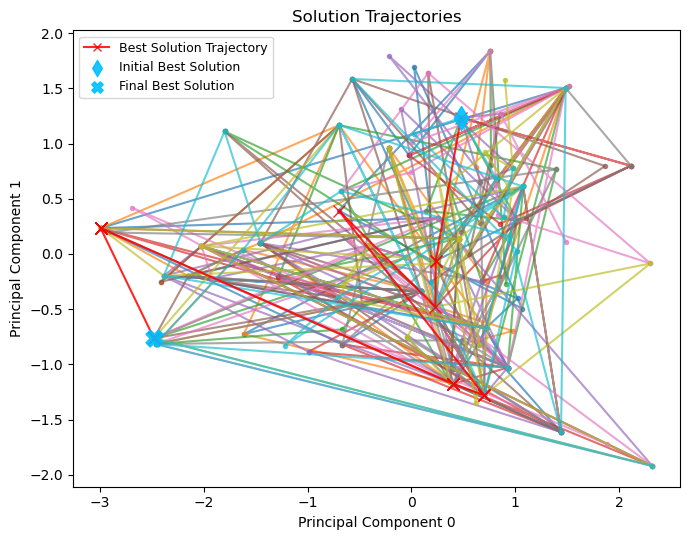


Monte Carlo RL fitness: -0.267

QUASAR fitness: -0.072
QUASAR reduced the average loss by 73.0% compared to MC.


In [4]:
import numpy as np
import gymnasium as gym
import hdim_opt

# objective function
def objective(params, n_hands=500):
    '''
    Returns negative average reward to minimize.
    'params' is a flat vector of 200 values (10x10x2 states).
    Values > 0.5 = Hit, Values <= 0.5 = Stick.
    '''
    env = gym.make('Blackjack-v1')
    # reshape the flat vector back into the (player sum, dealer, ace) grid
    policy_grid = params.reshape((10, 10, 2))
    
    total_reward = 0
    for _ in range(n_hands):
        state, _ = env.reset()
        done = False
        while not done:
            p_sum, d_card, ace = state
            if p_sum < 12: 
                action = 1 # never stick below 12
            else:
                # map to grid indices
                val = policy_grid[p_sum-12, d_card-1, int(ace)]
                action = 1 if val > 0.5 else 0
            
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        total_reward += reward
    
    env.close()
    return -(total_reward / n_hands) # return negative for minimization

### run evolution
# 200 parameters: (Player 12-21) x (Dealer 1-10) x (Usable Ace T/F)
bounds = [(0, 1)] * 200
result = hdim_opt.quasar(
    objective,
    bounds, 
    maxiter=30,
    popsize=2**4,
    init='hds',
    polish=False,
    seed=5
)

# final result
best_policy = result[0].reshape((10, 10, 2))
quasar_fitness = -result[1]

# average monte carlo score for comparison
rl_fitness = np.mean(history[-1000:])
print(f'\nMonte Carlo RL fitness: {rl_fitness:.3f}\n')
print(f'QUASAR fitness: {quasar_fitness:.3f}')

# percent improvement
loss_reduction = (1 - (quasar_fitness / rl_fitness)) * 100
print(f'QUASAR reduced the average loss by {loss_reduction:.1f}% compared to MC.')